In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys
import re
import numpy as np

In [5]:
ROOT_PATH = Path.cwd().resolve().parents[0]
DATA_PATH = ROOT_PATH / 'data' / 'processed'
OUTPUT_DIR = ROOT_PATH / 'figures' / 'unesco_exploratory'
inbound = pd.read_csv(DATA_PATH / 'inbound_students_processed.csv')
outbound = pd.read_csv(DATA_PATH / 'outbound_students_processed.csv')

In [6]:
# drop unneeded column and years after 2024 as there are few values
# also drop rows with nan country
inbound = inbound[inbound['year'] < 2024].drop(columns=['Unnamed: 0']).dropna(subset = ['country'])
outbound = outbound[outbound['year'] < 2024].drop(columns=['Unnamed: 0']).dropna(subset=['country'])

In [7]:
top_6_inbound = list(inbound.groupby('country')['value'].sum().sort_values(ascending=False)[0:6].index)
top_6_outbound = list(outbound.groupby('country')['value'].sum().sort_values(ascending=False)[0:6].index)

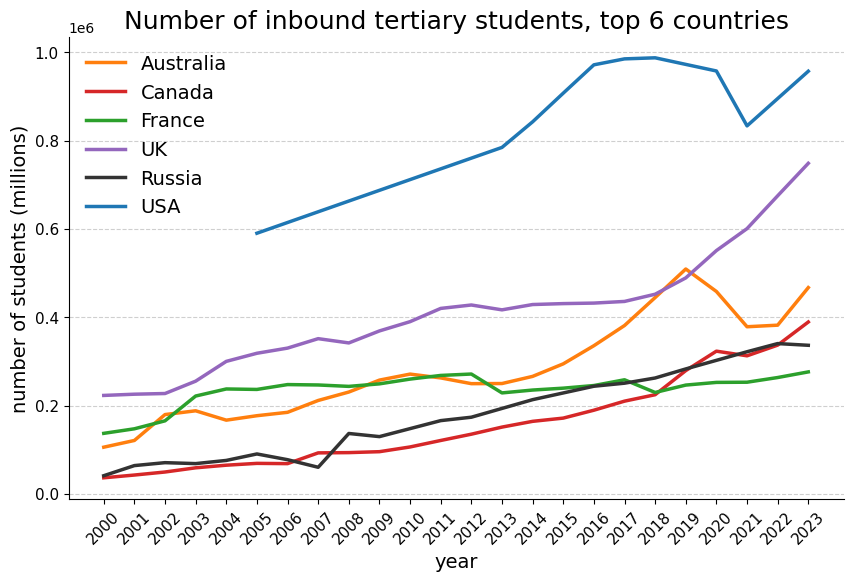

In [8]:
# plot top 6 countries by number of inbound and outbound students
plt.figure(figsize=(10,6))
cond = inbound['country'].isin(top_6_inbound)
country_colors = {
    'USA': '#1f77b4',     # Hex code for a nice blue
    'Australia': '#ff7f0e',  # Orange
    'Canada': '#d62728',   # Red
    'France': '#2ca02c',   # Green
    'UK': '#9467bd', # Purple
    'Russia': '#333333'
}
sns.lineplot(data = inbound[cond], x = 'year', y = 'value', hue = 'country',
             linewidth = 2.5,
             palette=country_colors)
plt.title('Number of inbound tertiary students, top 6 countries', fontsize = 18)
plt.ylabel('number of students (millions)', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(inbound['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

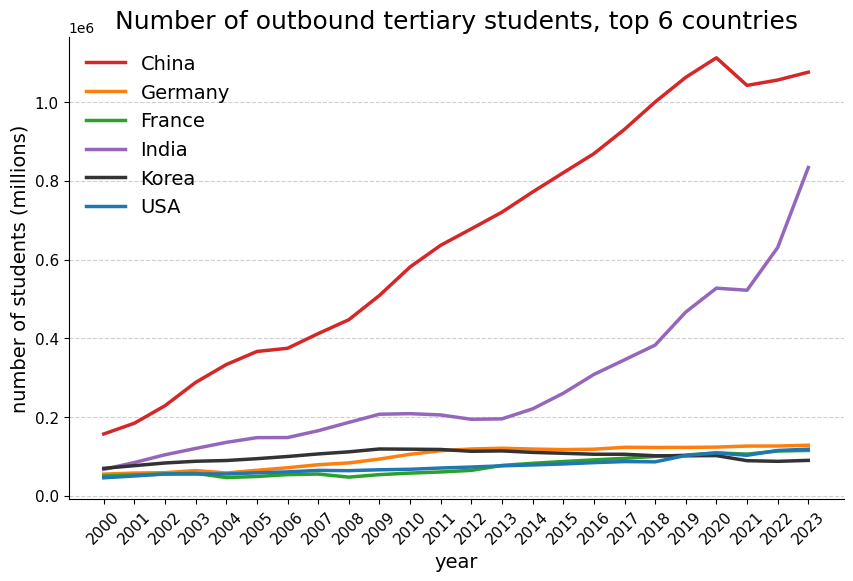

In [32]:
plt.figure(figsize=(10,6))
cond = outbound['country'].isin(top_6_outbound)
country_colors = {
    'USA': '#1f77b4',     # Hex code for a nice blue
    'Germany': '#ff7f0e',  # Orange
    'China': '#d62728',   # Red
    'France': '#2ca02c',   # Green
    'India': '#9467bd', # Purple
    'Korea': '#333333'
}
sns.lineplot(data = outbound[cond], x = 'year', y = 'value', hue = 'country',
             linewidth = 2.5,
             palette=country_colors)
plt.title('Number of outbound tertiary students, top 6 countries', fontsize = 18)
plt.ylabel('number of students (millions)', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(outbound['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

In [9]:
inbound = inbound.rename(columns = {'value': 'students'})
outbound = outbound.rename(columns = {'value': 'students'})


In [10]:
# merge inbound and outbound and calculate student flux
merged = inbound.merge(outbound, on=['country', 'year'], suffixes = ('_inbound', '_outbound')).drop(columns = ['geoUnit_outbound'])
merged['flux'] = merged['students_inbound'].sub(merged['students_outbound'])
merged['total_exchange'] = merged['students_inbound'].add(merged['students_outbound'])

In [11]:
top_10 = merged.groupby('country')['flux'].sum().sort_values(ascending=False)[0:10]
bottom_10 = merged.groupby('country')['flux'].sum().sort_values(ascending=True)[0:10]

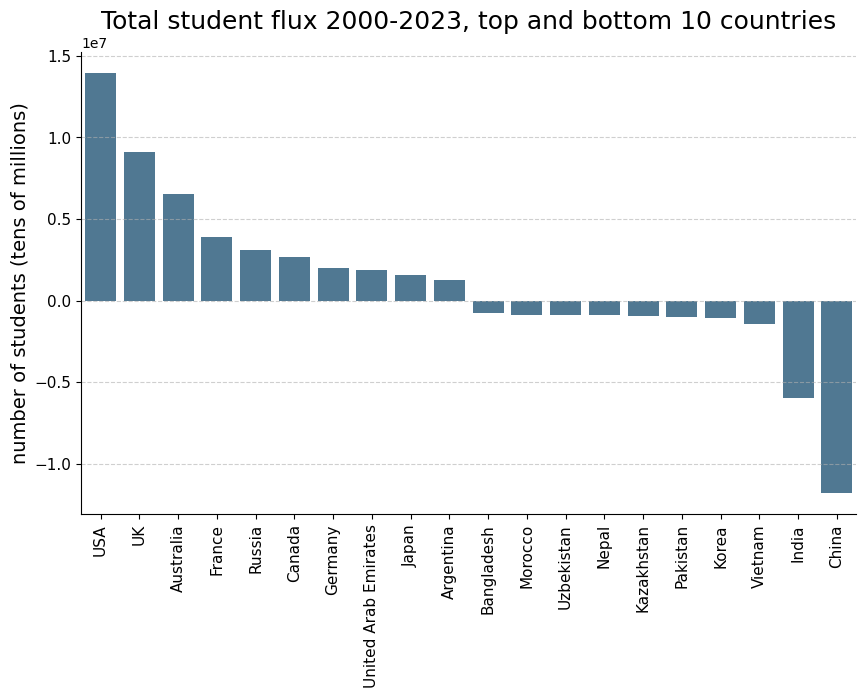

In [36]:
plot_series = pd.concat([top_10, bottom_10.sort_values(ascending=False)], axis=0)
plt.figure(figsize=(10,6))
# plot_series.index
# # plot_series.plot(kind='bar')
sns.barplot(data=plot_series, color = '#457b9d')
plt.title('Total student flux 2000-2023, top and bottom 10 countries', fontsize = 18)
plt.ylabel('number of students (tens of millions)', fontsize = 14)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_series.index.unique(), rotation=90, fontsize = 11)
# plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.show()

In [14]:
top_20_total_exchange = merged.groupby('country')['total_exchange'].sum().sort_values(ascending=False)[0:20]

In [15]:
list(top_20_total_exchange.index)

['USA',
 'China',
 'UK',
 'France',
 'India',
 'Australia',
 'Russia',
 'Canada',
 'Germany',
 'Korea',
 'Turkey',
 'Italy',
 'Malaysia',
 'Japan',
 'United Arab Emirates',
 'Saudi Arabia',
 'Spain',
 'Ukraine',
 'Netherlands',
 'Austria']

/var/folders/bc/ckv226vd2r767mrgsjn26yn80000gn/T/ipykernel_93763/1351024452.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize = 14)


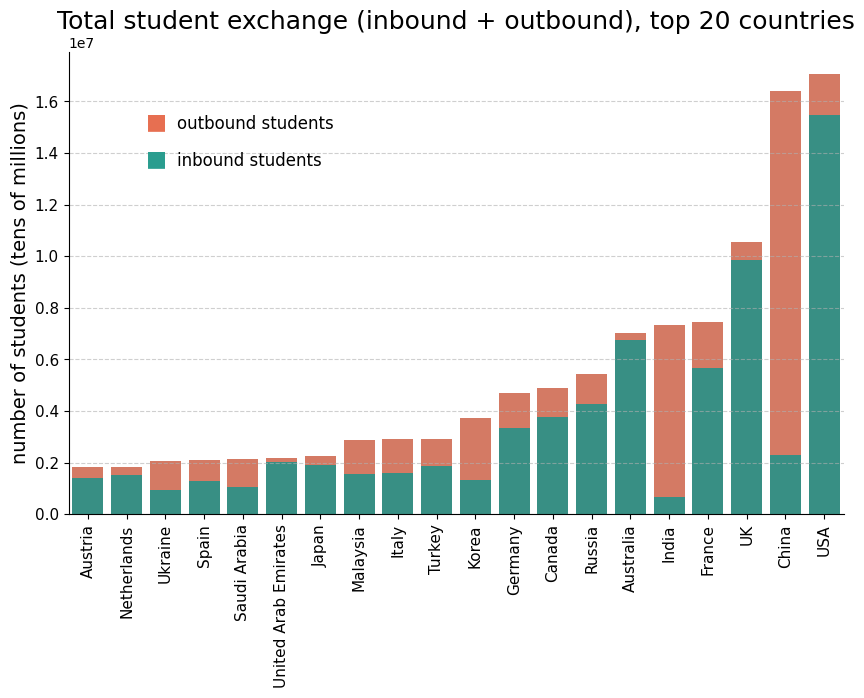

In [43]:
# plt.figure(figsize=(10,6))
fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=merged[merged['country'].isin(list(top_20_total_exchange.index))].groupby('country')['total_exchange'].sum().sort_values(),
            color = '#e76f51')
order = list(merged[merged['country'].isin(list(top_20_total_exchange.index))].groupby('country')['total_exchange'].sum().sort_values().index)
sns.barplot(data=merged[merged['country'].isin(list(top_20_total_exchange.index))].groupby('country')['students_inbound'].sum(),
            order = order,
            color = '#2a9d8f')
plt.title('Total student exchange (inbound + outbound), top 20 countries', fontsize = 18)
plt.ylabel('number of students (tens of millions)', fontsize = 14)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(rotation=90, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()

legend_data = [
    {"color": "#e76f51", "label": "outbound students"},
    {"color": "#2a9d8f", "label": "inbound students"}
]
start_x = 0.1
start_y = 0.85
line_spacing = 0.08  # How much to drop down for each legend item

for i, item in enumerate(legend_data):
    current_y = start_y - (i * line_spacing)
    
    # Draw the solid colored square (Using the \u25A0 unicode character)
    ax.text(
        x=start_x, 
        y=current_y, 
        s="■", 
        color=item["color"], 
        fontsize=16,          # Make the square slightly larger
        va="center", 
        ha="left",
        transform=ax.transAxes # Uses 0-1 coordinate system relative to the chart axes
    )
    
    # Draw the text label right next to it
    ax.text(
        x=start_x + 0.04,     # Shift the text slightly to the right of the square
        y=current_y - 0.005, 
        s=item["label"], 
        color="#000000",       # Clean dark charcoal for readability
        fontsize=12,
        va="center", 
        ha="left",
        transform=ax.transAxes
    )



plt.show()

In [ ]:
order = list(merged[merged['country'].isin(list(top_20_total_exchange.index))].groupby('country')['total_exchange'].sum().sort_values().index)

['Austria',
 'Netherlands',
 'Ukraine',
 'Spain',
 'Saudi Arabia',
 'United Arab Emirates',
 'Japan',
 'Malaysia',
 'Italy',
 'Turkey',
 'Korea',
 'Germany',
 'Canada',
 'Russia',
 'Australia',
 'India',
 'France',
 'UK',
 'China',
 'USA']